 # Working with Order Book Data: NASDAQ ITCH

 The primary source of market data is the order book, which is continuously updated in real-time throughout the day to reflect all trading activity. Exchanges typically offer this data as a real-time service and may provide some historical data for free.

 The trading activity is reflected in numerous messages about trade orders sent by market participants. These messages typically conform to the electronic Financial Information eXchange (FIX) communications protocol for real-time exchange of securities transactions and market data or a native exchange protocol.

 ## Background

 ### The FIX Protocol

 Just like SWIFT is the message protocol for back-office (example, for trade-settlement) messaging, the [FIX protocol](https://www.fixtrading.org/standards/) is the de facto messaging standard for communication before and during, trade execution between exchanges, banks, brokers, clearing firms, and other market participants. Fidelity Investments and Salomon Brothers introduced FIX in 1992 to facilitate electronic communication between broker-dealers and institutional clients who by then exchanged information over the phone.

 It became popular in global equity markets before expanding into foreign exchange, fixed income and derivatives markets, and further into post-trade to support straight-through processing. Exchanges provide access to FIX messages as a real-time data feed that is parsed by algorithmic traders to track market activity and, for example, identify the footprint of market participants and anticipate their next move.

 ### Nasdaq TotalView-ITCH Order Book data

 While FIX has a dominant large market share, exchanges also offer native protocols. The Nasdaq offers a [TotalView ITCH direct data-feed protocol](http://www.nasdaqtrader.com/content/technicalsupport/specifications/dataproducts/NQTVITCHspecification.pdf) that allows subscribers to track
 individual orders for equity instruments from placement to execution or cancellation.

 As a result, it allows for the reconstruction of the order book that keeps track of the list of active-limit buy and sell orders for a specific security or financial instrument. The order book reveals the market depth throughout the day by listing the number of shares being bid or offered at each price point. It may also identify the market participant responsible for specific buy and sell orders unless it is placed anonymously. Market depth is a key indicator of liquidity and the potential price impact of sizable market orders.

 The ITCH v5.0 specification declares over 20 message types related to system events, stock characteristics, the placement and modification of limit orders, and trade execution. It also contains information about the net order imbalance before the open and closing cross.

 ## Imports

In [1]:
# %pip install matplotlib
# %pip install seaborn
# %pip install openpyxl

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import traceback
import gzip
import shutil
import struct
import os
import platform
import subprocess
import ctypes
from struct import unpack
from collections import namedtuple, Counter, defaultdict
from pathlib import Path
from urllib.request import urlretrieve
from urllib.parse import urljoin
from datetime import timedelta
from time import time

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

In [4]:
sns.set_style('whitegrid')

In [5]:
def format_time(t):
    """Return a formatted time string 'HH:MM:SS
    based on a numeric time() value"""
    m, s = divmod(t, 60)
    h, m = divmod(m, 60)
    return f'{h:0>2.0f}:{m:0>2.0f}:{s:0>5.2f}'

 ## Get NASDAQ ITCH Data from FTP Server

 The Nasdaq offers [samples](https://emi.nasdaq.com/ITCH/Nasdaq%20ITCH/) of daily binary files for several months.

 We are now going to illustrates how to parse a sample file of ITCH messages and reconstruct both the executed trades and the order book for any given tick.

 The data is fairly large and running the entire example can take a lot of time and require substantial memory (16GB+). Also, the sample file used in this example may no longer be available because NASDAQ occasionaly updates the sample files.

 The following table shows the frequency of the most common message types for the sample file date March 29, 2018:

 | Name                    | Offset  | Length  | Value      | Notes                                                                                |
 |-------------------------|---------|---------|------------|--------------------------------------------------------------------------------------|
 | Message Type            | 0       | 1       | S          | System Event Message                                                                 |
 | Stock Locate            | 1       | 2       | Integer    | Always 0                                                                             |
 | Tracking Number         | 3       | 2       | Integer    | Nasdaq internal tracking number                                                      |
 | Timestamp               | 5       | 6       | Integer    | Nanoseconds since midnight                                                           |
 | Order Reference Number  | 11      | 8       | Integer    | The unique reference number assigned to the new order at the time of receipt.        |
 | Buy/Sell Indicator      | 19      | 1       | Alpha      | The type of order being added. B = Buy Order. S = Sell Order.                        |
 | Shares                  | 20      | 4       | Integer    | The total number of shares associated with the order being added to the book.        |
 | Stock                   | 24      | 8       | Alpha      | Stock symbol, right padded with spaces                                               |
 | Price                   | 32      | 4       | Price (4)  | The display price of the new order. Refer to Data Types for field processing notes.  |
 | Attribution             | 36      | 4       | Alpha      | Nasdaq Market participant identifier associated with the entered order               |

 ### Set Data paths

 We will store the download in a `data` subdirectory and convert the result to `hdf` format (discussed in the last section of chapter 2).

In [6]:
data_path = Path('data') # set to e.g. external harddrive

 You can find several sample files on the [NASDAQ server](https://emi.nasdaq.com/ITCH/Nasdaq%20ITCH/).

 The HTTPS address, filename and corresponding date used in this example:

In [7]:
HTTPS_URL = 'https://emi.nasdaq.com/ITCH/Nasdaq%20ITCH/'
SOURCE_FILE = '10302019.NASDAQ_ITCH50.gz'

 Derive HDF5 output filename from source file (e.g. '10302019.NASDAQ_ITCH50.h5')

In [8]:
itch_store = str(data_path / (Path(SOURCE_FILE).stem + '.h5'))
order_book_store = data_path / (Path(SOURCE_FILE).stem + '_order_book.h5')

 #### URL updates

 NASDAQ updates the files occasionally so that the SOURCE_FILE changes. If the above gives an error, navigate to the HTTPS_URL using your browser, and check for new files. As of September 2021, the listed files include:

 - 01302020.NASDAQ_ITCH50.gz
 - 12302019.NASDAQ_ITCH50.gz
 - 10302019.NASDAQ_ITCH50.gz
 - 08302019.NASDAQ_ITCH50.gz
 - 07302019.NASDAQ_ITCH50.gz
 - 03272019.NASDAQ_ITCH50.gz
 - 01302019.NASDAQ_ITCH50.gz
 - 12282018.NASDAQ_ITCH50.gz


 ### Download & unzip

In [9]:
def may_be_download(url):
    """Download & unzip ITCH data if not yet available"""
    if not data_path.exists():
        print('Creating directory')
        data_path.mkdir()
    else: 
        print('Directory exists')

    filename = data_path / url.split('/')[-1]        
    if not filename.exists():
        print('Downloading...', url)
        urlretrieve(url, filename)
    else: 
        print('File exists')        

    unzipped = data_path / (filename.stem + '.bin')
    if not unzipped.exists():
        print('Unzipping to', unzipped)
        with gzip.open(str(filename), 'rb') as f_in:
            with open(unzipped, 'wb') as f_out:
                shutil.copyfileobj(f_in, f_out)
    else: 
        print('File already unpacked')
    return unzipped

 This will download 5.1GB data that unzips to 12.9GB (this may vary depending on the file, see 'url updates' below).

In [10]:
file_name = may_be_download(urljoin(HTTPS_URL, SOURCE_FILE))
date = file_name.name.split('.')[0]

Directory exists
File exists
File already unpacked


 ## ITCH Format Settings

 ### The `struct` module for binary data

 The ITCH tick data comes in binary format. Python provides the `struct` module (see [docs](https://docs.python.org/3/library/struct.html)) to parse binary data using format strings that identify the message elements by indicating length and type of the various components of the byte string as laid out in the specification.

 From the docs:

 > This module performs conversions between Python values and C structs represented as Python bytes objects. This can be used in handling binary data stored in files or from network connections, among other sources. It uses Format Strings as compact descriptions of the layout of the C structs and the intended conversion to/from Python values.

 Let's walk through the critical steps to parse the trading messages and reconstruct the order book:

 ### Defining format strings

 The parser uses format strings according to the following formats dictionaries:

In [11]:
event_codes = {'O': 'Start of Messages',
               'S': 'Start of System Hours',
               'Q': 'Start of Market Hours',
               'M': 'End of Market Hours',
               'E': 'End of System Hours',
               'C': 'End of Messages'}

In [12]:
encoding = {'primary_market_maker': {'Y': 1, 'N': 0},
            'printable'           : {'Y': 1, 'N': 0},
            'buy_sell_indicator'  : {'B': 1, 'S': -1},
            'cross_type'          : {'O': 0, 'C': 1, 'H': 2},
            'imbalance_direction' : {'B': 0, 'S': 1, 'N': 0, 'O': -1}}

In [13]:
formats = {
    ('integer', 2): 'H',  # int of length 2 => format string 'H'
    ('integer', 4): 'I',
    ('integer', 6): '6s',  # int of length 6 => parse as string, convert later
    ('integer', 8): 'Q',
    ('alpha',   1): 's',
    ('alpha',   2): '2s',
    ('alpha',   4): '4s',
    ('alpha',   8): '8s',
    ('price_4', 4): 'I',
    ('price_8', 8): 'Q',
}

 ### Create message specs for binary data parser

 The ITCH parser relies on message specifications that we create in the following steps.

 #### Load Message Types

 The file `message_types.xlxs` contains the message type specs as laid out in the [documentation](https://www.nasdaqtrader.com/content/technicalsupport/specifications/dataproducts/NQTVITCHSpecification.pdf)

In [14]:
message_data = (pd.read_excel('message_types.xlsx',
                              sheet_name='messages')
                .sort_values('id')
                .drop('id', axis=1))

In [15]:
message_data.head()

,Name,Offset,Length,Value,Notes
0,Message Type,0,1,S,System Event Message
1,Stock Locate,1,2,Integer,Always 0
2,Tracking Number,3,2,Integer,Nasdaq internal tracking number
3,Timestamp,5,6,Integer,Nanoseconds since midnight
4,Event Code,11,1,Alpha,See System Event Codes below


 #### Basic Cleaning

 The function `clean_message_types()` just runs a few basic string cleaning steps.

In [16]:
def clean_message_types(df):
    df.columns = [c.lower().strip() for c in df.columns]
    df.value = df.value.str.strip()
    df.name = (df.name
               .str.strip() # remove whitespace
               .str.lower()
               .str.replace(' ', '_')
               .str.replace('-', '_')
               .str.replace('/', '_'))
    df.notes = df.notes.str.strip()
    df['message_type'] = df.loc[df.name == 'message_type', 'value']
    return df

In [17]:
message_types = clean_message_types(message_data)

 #### Get Message Labels

 We extract message type codes and names so we can later make the results more readable.

In [18]:
message_labels = (message_types.loc[:, ['message_type', 'notes']]
                  .dropna()
                  .rename(columns={'notes': 'name'}))
message_labels.name = (message_labels.name
                       .str.lower()
                       .str.replace('message', '')
                       .str.replace('.', '')
                       .str.strip().str.replace(' ', '_'))
# message_labels.to_csv('message_labels.csv', index=False)
message_labels.head()

,message_type,name
0,S,system_event
5,R,stock_directory
23,H,stock_trading_action
31,Y,reg_sho_short_sale_price_test_restricted_indic...
37,L,market_participant_position


 ### Finalize specification details

 Each message consists of several fields that are defined by offset, length and type of value. The `struct` module will use this format information to parse the binary source data.

In [19]:
message_types.message_type = message_types.message_type.ffill()
message_types = message_types[message_types.name != 'message_type']
message_types.value = (message_types.value
                       .str.lower()
                       .str.replace(' ', '_')
                       .str.replace('(', '')
                       .str.replace(')', ''))
message_types.info()

<class 'pandas.DataFrame'>
Index: 152 entries, 1 to 172
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   name          152 non-null    str  
 1   offset        152 non-null    int64
 2   length        152 non-null    int64
 3   value         152 non-null    str  
 4   notes         152 non-null    str  
 5   message_type  152 non-null    str  
dtypes: int64(2), str(4)
memory usage: 8.3 KB


In [20]:
message_types.head()

,name,offset,length,value,notes,message_type
1,stock_locate,1,2,integer,Always 0,S
2,tracking_number,3,2,integer,Nasdaq internal tracking number,S
3,timestamp,5,6,integer,Nanoseconds since midnight,S
4,event_code,11,1,alpha,See System Event Codes below,S
6,stock_locate,1,2,integer,Locate Code uniquely assigned to the security ...,R


 Optionally, persist/reload from file:

In [21]:
message_types.to_csv('message_types.csv', index=False)

In [22]:
message_types = pd.read_csv('message_types.csv')

 The parser translates the message specs into format strings and `namedtuples` that capture the message content. First, we create `(type, length)` formatting tuples from ITCH specs:

In [23]:
message_types.loc[:, 'formats'] = (message_types[['value', 'length']]
                            .apply(tuple, axis=1).map(formats))

 Then, we extract formatting details for alphanumerical fields

In [24]:
alpha_fields = message_types[message_types.value == 'alpha'].set_index('name')
alpha_msgs = alpha_fields.groupby('message_type')
alpha_formats = {k: v.to_dict() for k, v in alpha_msgs.formats}
alpha_length = {k: v.add(5).to_dict() for k, v in alpha_msgs.length}

 We generate message classes as named tuples and format strings

In [25]:
message_fields, fstring, fstring_size = {}, {}, {}
for t, message in message_types.groupby('message_type'):
    message_fields[t] = namedtuple(typename=t, field_names=message.name.tolist())
    fstring[t] = '>' + ''.join(message.formats.tolist())
    fstring_size[t] = struct.calcsize(fstring[t])

In [26]:
alpha_fields.info()

<class 'pandas.DataFrame'>
Index: 45 entries, event_code to price_variation_indicator
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   offset        45 non-null     int64
 1   length        45 non-null     int64
 2   value         45 non-null     str  
 3   notes         45 non-null     str  
 4   message_type  45 non-null     str  
 5   formats       45 non-null     str  
dtypes: int64(2), str(4)
memory usage: 2.5+ KB


In [27]:
alpha_fields.head()

,offset,length,value,notes,message_type,formats
name,,,,,,
event_code,11,1,alpha,See System Event Codes below,S,s
stock,11,8,alpha,Denotes the security symbol for the issue in t...,R,8s
market_category,19,1,alpha,Indicates Listing market or listing market tie...,R,s
financial_status_indicator,20,1,alpha,"For Nasdaq listed issues, this field indicates...",R,s
round_lots_only,25,1,alpha,Indicates if Nasdaq system limits order entry ...,R,s


 Fields of `alpha` type (alphanumeric) require post-processing as defined in the `format_alpha` function:

In [28]:
def format_alpha(mtype, data):
    """Process byte strings of type alpha"""

    for col in alpha_formats.get(mtype).keys():
        if mtype != 'R' and col == 'stock':
            data = data.drop(col, axis=1)
            continue
        data.loc[:, col] = data.loc[:, col].str.decode("utf-8").str.strip()
        if encoding.get(col):
            # Enforce numeric types cleanly to bypass PyTables strict object/string min_itemsize serialization bugs
            data.loc[:, col] = pd.to_numeric(data.loc[:, col].map(encoding.get(col)), downcast='integer')
            data[col] = pd.to_numeric(data[col], errors='coerce')
    return data

 ## Process Binary Message Data

 The binary file for a single day contains over 350,000,000 messages worth over 12 GB.

In [29]:
def fast_timestamp_convert(ts_series):
    """Convert 6-byte big-endian timestamps to nanosecond timedeltas — fully vectorized.
    
    Uses numpy bit-shifting instead of Python list comprehension to avoid
    creating N intermediate byte objects.
    """
    raw6 = np.array(ts_series.tolist(), dtype='S6')
    b = raw6.view(np.uint8).reshape(-1, 6)
    ns = (b[:, 0].astype(np.uint64) << 40 |
          b[:, 1].astype(np.uint64) << 32 |
          b[:, 2].astype(np.uint64) << 24 |
          b[:, 3].astype(np.uint64) << 16 |
          b[:, 4].astype(np.uint64) << 8  |
          b[:, 5].astype(np.uint64))
    return pd.to_timedelta(ns)

In [30]:
def store_messages(m):
    """Store parsed messages to HDF5 using fixed format (5-10× faster than table format).
    
    Fixed format skips per-row indexing. Downstream scripts load full tables
    and filter in memory, which is fast with 128GB RAM.
    """
    with pd.HDFStore(itch_store) as store:
        for mtype, data in m.items():
            t0 = time()
            # convert list of tuples to DataFrame using field names
            data = pd.DataFrame(data, columns=message_fields[mtype]._fields)

            # parse timestamp info — vectorized with NumPy bit-shifting
            data['timestamp'] = fast_timestamp_convert(data['timestamp'])

            # apply alpha formatting
            if mtype in alpha_formats.keys():
                data = format_alpha(mtype, data)

            try:
                # Fixed format: no min_itemsize, no data_columns, no format='t'
                store.put(mtype, data)
                print(f'\t{mtype}: {len(data):>12,} rows stored in {time()-t0:.1f}s')
            except Exception as e:
                print(e)
                print(mtype)
                print(data.info())
                data.to_csv('data.csv', index=False)
                return 1
    return 0

 The script parses the data and stores it in the fast HDF5 format.

 ## V3 Universal Adaptive ITCH Parser

 Key features:
 1. **System Auto-Detection**: Selects strategy based on available RAM vs file size.
 2. **C Scanner**: Compiles a tiny C extension on the fly for 50x faster scanning.
 3. **Merged Per-Type Processing**: Unpacks and stores one message type at a time, drastically reducing peak memory compared to reading everything into memory at once.

In [31]:
# Clean up stale HDF5 file to prevent duplicate appends
itch_path = Path(itch_store)
if itch_path.exists():
    print(f'Removing existing {itch_store} ({itch_path.stat().st_size / 1e9:.1f} GB)')
    itch_path.unlink()

In [32]:
def get_system_config():
    """Detect RAM and CPU for adaptive optimization."""
    if platform.system() == 'Darwin':
        try:
            ram_bytes = int(subprocess.check_output(['sysctl', '-n', 'hw.memsize']))
        except Exception:
            ram_bytes = os.sysconf('SC_PAGE_SIZE') * os.sysconf('SC_PHYS_PAGES')
    else:
        ram_bytes = os.sysconf('SC_PAGE_SIZE') * os.sysconf('SC_PHYS_PAGES')
    return {
        'ram_gb': ram_bytes / (1024**3),
        'cpu_cores': os.cpu_count() or 4,
        'platform': platform.system(),
        'arch': platform.machine(),
    }

sys_config = get_system_config()
file_size_gb = file_name.stat().st_size / (1024**3)

print("=== System Config ===")
print(f"RAM:      {sys_config['ram_gb']:.1f} GB")
print(f"CPU:      {sys_config['cpu_cores']} cores ({sys_config['arch']})")
print(f"File:     {file_size_gb:.1f} GB ({file_name.name})")

if sys_config['ram_gb'] >= file_size_gb * 4:
    strategy = 'full'
elif sys_config['ram_gb'] >= file_size_gb * 2:
    strategy = 'per_type'
else:
    strategy = 'batched'
    print("WARNING: Batched strategy for <18GB RAM not fully implemented. Attempting per_type...")
    strategy = 'per_type'

print(f"Strategy: {strategy} (based on RAM/File ratio)")
print("=====================\n")

=== System Config ===
RAM:      121.7 GB
CPU:      20 cores (aarch64)
File:     8.4 GB (10302019.NASDAQ_ITCH50.bin)
Strategy: full (based on RAM/File ratio)



In [34]:
# Compile C scanner if available (__file__ is undefined in Jupyter)
if '__file__' in globals():
    _itch_scanner_dir = Path(__file__).resolve().parent
else:
    _itch_scanner_dir = Path.cwd().resolve()
    _nested = _itch_scanner_dir / '02_market_and_fundamental_data/01_NASDAQ_TotalView-ITCH_Order_Book'
    if (_nested / 'itch_scanner.c').exists():
        _itch_scanner_dir = _nested

c_scanner = None
scanner_lib_path = _itch_scanner_dir / ('itch_scanner.dylib' if sys_config['platform'] == 'Darwin' else 'itch_scanner.so')
try:
    if not scanner_lib_path.exists() or _itch_scanner_dir.joinpath('itch_scanner.c').stat().st_mtime > scanner_lib_path.stat().st_mtime:
        print("Compiling C scanner extension...")
        compile_cmd = ['cc', '-O3', '-shared', '-fPIC', '-o', str(scanner_lib_path), str(_itch_scanner_dir / 'itch_scanner.c')]
        subprocess.run(compile_cmd, check=True, capture_output=True)
    
    c_scanner = ctypes.CDLL(str(scanner_lib_path))
    c_scanner.scan_itch.argtypes = [
        ctypes.c_char_p, ctypes.c_size_t, 
        ctypes.POINTER(ctypes.c_uint64), ctypes.POINTER(ctypes.c_uint8), 
        ctypes.c_int
    ]
    c_scanner.scan_itch.restype = ctypes.c_int
    print("C scanner ready.")
except Exception as e:
    print(f"Failed to load C scanner: {e}. Falling back to Python scanner.")

Compiling C scanner extension...
C scanner ready.


In [35]:
# Pre-compile struct objects (eliminates ~200ns of format parsing per unpack call)
compiled = {t: struct.Struct(fmt) for t, fmt in fstring.items()}

In [36]:
start_time = time()

# Load entire binary file into memory for zero-copy access
print(f'Loading {file_name} into memory...')
t0 = time()
raw = file_name.read_bytes()
buf = memoryview(raw)
total_len = len(raw)
print(f'Loaded {total_len / 1e9:.2f} GB in {time() - t0:.1f}s')

print('\nPass 1: Scanning message boundaries...')
scan_start = time()

# 350 million messages max estimate for pre-allocation
MAX_MSGS = 350_000_000 

if c_scanner:
    # Use C scanner
    print("Using ultra-fast C scanner...")
    offsets_array = (ctypes.c_uint64 * MAX_MSGS)()
    types_array = (ctypes.c_uint8 * MAX_MSGS)()
    
    msg_count = c_scanner.scan_itch(
        raw, total_len, offsets_array, types_array, MAX_MSGS
    )
    print(f'\nScan complete: {msg_count:,} messages in {time() - scan_start:.1f}s')
    
    # Group offsets by type
    offsets_by_type = defaultdict(list)
    for i in range(msg_count):
        offsets_by_type[types_array[i]].append(offsets_array[i])
        
    del offsets_array, types_array
else:
    # Use Python scanner fallback
    offsets_by_type = defaultdict(list)
    pos = 0
    msg_count = 0
    
    while pos + 2 < total_len:
        msg_size = (buf[pos] << 8) | buf[pos + 1]
        if msg_size == 0: break
        
        mt_byte = buf[pos + 2]
        offsets_by_type[mt_byte].append(pos)
        
        if mt_byte == 83:  # 'S'
            event_data = compiled['S'].unpack_from(buf, pos + 3)
            if event_data[3].decode('ascii') == 'C':
                pos += 2 + msg_size
                msg_count += 1
                break
        
        pos += 2 + msg_size
        msg_count += 1
        if msg_count % 50_000_000 == 0:
            print(f'\tScanned {msg_count:>12,} messages in {time() - scan_start:.1f}s')
            
    print(f'\nScan complete: {msg_count:,} messages in {time() - scan_start:.1f}s')

message_type_counter = Counter({chr(k): len(v) for k, v in offsets_by_type.items()})

print('\nPass 2: Merged Unpack & Store (Adaptive)...')
unpack_start = time()

with pd.HDFStore(itch_store) as store:
    for mt_byte, type_offsets in sorted(offsets_by_type.items(), key=lambda x: -len(x[1])):
        mt = chr(mt_byte)
        s = compiled[mt]
        t0 = time()
        
        # 1. Unpack
        tuples = [s.unpack_from(buf, off + 3) for off in type_offsets]
        
        # 2. DataFrame + Timestamps
        df = pd.DataFrame(tuples, columns=message_fields[mt]._fields)
        df['timestamp'] = fast_timestamp_convert(df['timestamp'])
        
        # 3. Alpha Formatting
        if mt in alpha_formats:
            df = format_alpha(mt, df)
            
        # 4. Store (Fixed format)
        store.put(mt, df)
        
        print(f'\t{mt}: {len(type_offsets):>12,} messages unpacked & stored in {time()-t0:.1f}s')
        
        # 5. Free memory immediately
        del tuples, df

print(f'\nUnpack & store complete in {time() - unpack_start:.1f}s')

del buf, raw

print(f'\nTotal Duration: {format_time(time() - start_time)}')

Loading data/10302019.NASDAQ_ITCH50.bin into memory...
Loaded 9.04 GB in 2.5s

Pass 1: Scanning message boundaries...
Using ultra-fast C scanner...

Scan complete: 293,989,079 messages in 1.8s

Pass 2: Merged Unpack & Store (Adaptive)...
	A:  127,214,649 messages unpacked & stored in 163.7s
	D:  123,296,742 messages unpacked & stored in 115.4s
	U:   25,513,651 messages unpacked & stored in 26.0s
	E:    7,316,703 messages unpacked & stored in 7.0s
	I:    3,740,140 messages unpacked & stored in 7.2s
	X:    3,568,735 messages unpacked & stored in 3.0s
	P:    1,525,363 messages unpacked & stored in 2.3s
	F:    1,423,908 messages unpacked & stored in 2.5s
	L:      214,865 messages unpacked & stored in 0.4s
	C:      129,729 messages unpacked & stored in 0.2s
	Q:       17,775 messages unpacked & stored in 0.0s
	Y:        9,025 messages unpacked & stored in 0.0s
	H:        8,897 messages unpacked & stored in 0.0s
	R:        8,887 messages unpacked & stored in 0.0s
	S:            6 messages unp

 ## Summarize Trading Day

 ### Trading Message Frequency

In [37]:
counter = pd.Series(message_type_counter).to_frame('# Trades')
counter['Message Type'] = counter.index.map(message_labels.set_index('message_type').name.to_dict())
counter = counter[['Message Type', '# Trades']].sort_values('# Trades', ascending=False)
counter

,Message Type,# Trades
A,add_order_no_mpid_attribution,127214649
D,order_delete,123296742
U,order_replace,25513651
E,order_executed,7316703
I,noii,3740140
X,order_cancel,3568735
P,trade,1525363
F,add_order_mpid_attribution,1423908
L,market_participant_position,214865
C,order_executed_with_price,129729


In [38]:
with pd.HDFStore(itch_store) as store:
    store.put('summary', counter)

 ### Top Equities by Traded Value

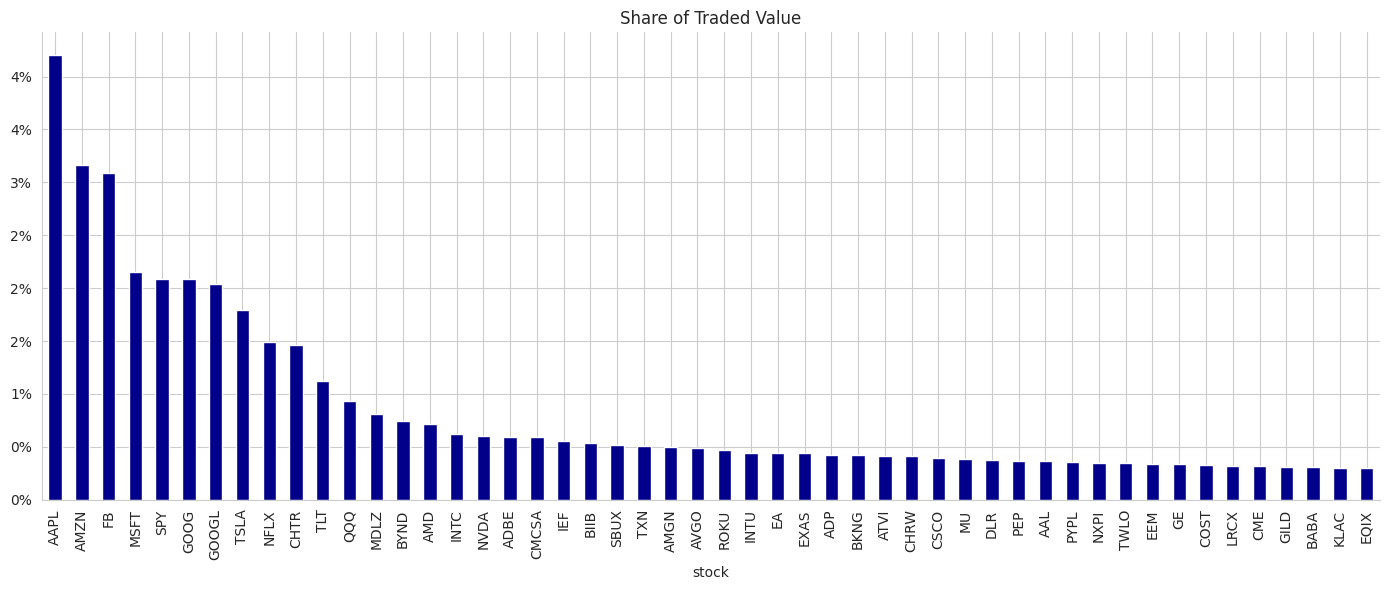

In [39]:
with pd.HDFStore(itch_store) as store:
    stocks = store['R'].loc[:, ['stock_locate', 'stock']]
    trade_dfs = []
    if '/P' in store.keys():
        trade_dfs.append(store['P'])
    if '/Q' in store.keys():
        trade_dfs.append(store['Q'].rename(columns={'cross_price': 'price'}))
    if not trade_dfs:
        print("Warning: No trade data (P or Q) found in store.")
        trades = pd.DataFrame(columns=['stock_locate', 'stock', 'shares', 'price', 'value', 'value_share'])
    else:
        trades = pd.concat(trade_dfs, sort=False, ignore_index=True)
        trades = trades.merge(stocks)
        trades['value'] = trades.shares.mul(trades.price)
        trades['value_share'] = trades.value.div(trades.value.sum())

if len(trades) > 0 and 'value_share' in trades.columns:
    trade_summary = trades.groupby('stock').value_share.sum().sort_values(ascending=False)
    trade_summary.iloc[:50].plot.bar(figsize=(14, 6), color='darkblue', title='Share of Traded Value')

    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    sns.despine()
    plt.tight_layout()
else:
    print("No trades to summarize or plot.")